In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.preprocessing import StandardScaler
from feature_engineering import add_trend_features

In [ ]:
df = pd.read_csv('data/dataset-no-recessions.csv', parse_dates=['Date']).set_index('Date').sort_index()
df = add_trend_features(df)

START_EVAL_YEAR = 2000
TRAIN_WINDOW_YEARS = 30
ALPHAS = [1.0, 0.1, 0.01, 0.001, 0.0001, 0.00001]
MC = {'Ridge': 'steelblue', 'Lasso': 'darkorange', 'Linear': 'forestgreen'}


def build_folds(H):
    y_future = df['BAA10Y'].shift(-H)
    y_now    = df['BAA10Y']
    X_full   = df.drop(columns=['BAA10Y']).copy()
    X_full['BAA10Y_current'] = df['BAA10Y']

    mask = y_future.notna() & y_now.notna() & X_full.notna().all(axis=1)
    X, y, y_t = X_full.loc[mask], y_future.loc[mask], y_now.loc[mask]

    folds = []
    for year in range(START_EVAL_YEAR, y.index.year.max() + 1):
        # Rolling 30-year window: use at most the last 30 years of training data.
        # Falls back to all available data when fewer than 30 years exist.
        train_start = max(X.index.min(), pd.Timestamp(f"{year - TRAIN_WINDOW_YEARS}-10-01"))
        train_end  = pd.Timestamp(f"{year}-09-30")
        test_start = pd.Timestamp(f"{year}-10-01")
        test_end   = pd.Timestamp(f"{year}-12-31")
        tr = (X.index >= train_start) & (X.index <= train_end)
        te = (X.index >= test_start) & (X.index <= test_end)
        if tr.sum() > 0 and te.sum() > 0:
            folds.append({
                'year':     year,
                'X_train':  X.loc[tr],  'y_train': y.loc[tr],
                'X_test':   X.loc[te],  'y_test':  y.loc[te],
                'y_t_test': y_t.loc[te],
            })
    return folds


def run_walk_forward(folds):
    fold_results = []
    all_preds    = {'Ridge': [], 'Lasso': [], 'Linear': [], 'Naive': []}
    all_y_test   = []
    all_y_curr   = []
    lasso_coefs  = []

    for fold in folds:
        scaler  = StandardScaler()
        X_tr_sc = scaler.fit_transform(fold['X_train'])
        X_te_sc = scaler.transform(fold['X_test'])
        y_tr, y_te, y_curr = fold['y_train'], fold['y_test'], fold['y_t_test']

        val_cut = int(len(X_tr_sc) * 0.80)
        X_cv_tr,  y_cv_tr  = X_tr_sc[:val_cut], y_tr.iloc[:val_cut]
        X_cv_val, y_cv_val = X_tr_sc[val_cut:],  y_tr.iloc[val_cut:]
        best_alpha, best_val_mse = ALPHAS[0], np.inf
        for alpha in ALPHAS:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                m = Lasso(alpha=alpha, max_iter=10000)
                m.fit(X_cv_tr, y_cv_tr)
            val_mse = mean_squared_error(y_cv_val, m.predict(X_cv_val))
            if val_mse < best_val_mse:
                best_val_mse, best_alpha = val_mse, alpha

        ridge  = Ridge()
        lasso  = Lasso(alpha=best_alpha, max_iter=10000)
        linear = LinearRegression()
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            for m in (ridge, lasso, linear):
                m.fit(X_tr_sc, y_tr)
        lasso_coefs.append(lasso.coef_.copy())

        preds_fold = {
            'Ridge':  pd.Series(ridge.predict(X_te_sc),  index=y_te.index),
            'Lasso':  pd.Series(lasso.predict(X_te_sc),  index=y_te.index),
            'Linear': pd.Series(linear.predict(X_te_sc), index=y_te.index),
            'Naive':  y_curr,
        }

        row = {'year': fold['year'], 'n_test': len(y_te), 'lasso_alpha': best_alpha}
        for name, pred in preds_fold.items():
            mae  = mean_absolute_error(y_te, pred)
            rmse = np.sqrt(mean_squared_error(y_te, pred))
            ss_res = ((y_te.values - pred.values) ** 2).sum()
            ss_tot = ((y_te.values - y_te.values.mean()) ** 2).sum()
            r2  = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
            act = np.sign(y_te.values - y_curr.values)
            prd = np.sign(pred.values  - y_curr.values)
            nf  = act != 0
            da  = (act[nf] == prd[nf]).mean() if nf.sum() > 0 else np.nan
            row[f'MAE_{name}'], row[f'RMSE_{name}'] = mae, rmse
            row[f'R2_{name}'],  row[f'DirAcc_{name}'] = r2, da
        fold_results.append(row)

        for name, pred in preds_fold.items():
            all_preds[name].append(pred)
        all_y_test.append(y_te)
        all_y_curr.append(y_curr)

        print(f"{fold['year']}: Ridge R²={row['R2_Ridge']:6.3f}  "
              f"Lasso(α={best_alpha}) R²={row['R2_Lasso']:6.3f}  "
              f"Linear R²={row['R2_Linear']:6.3f}  "
              f"Naive MAE={row['MAE_Naive']:.4f}")

    results_df = pd.DataFrame(fold_results).set_index('year')
    y_test_all = pd.concat(all_y_test)
    y_curr_all = pd.concat(all_y_curr)
    preds_all  = {name: pd.concat(segs) for name, segs in all_preds.items()}

    print(f"\n{'Model':8} {'Mean MAE':>9} {'Mean RMSE':>10} {'Mean R²':>9} {'DirAcc':>8}")
    print("-" * 48)
    for name in ['Ridge', 'Lasso', 'Linear', 'Naive']:
        print(f"{name:8} "
              f"{results_df[f'MAE_{name}'].mean():>9.4f} "
              f"{results_df[f'RMSE_{name}'].mean():>10.4f} "
              f"{results_df[f'R2_{name}'].mean():>9.3f} "
              f"{results_df[f'DirAcc_{name}'].mean():>8.2%}")

    return results_df, y_test_all, y_curr_all, preds_all, np.array(lasso_coefs)


def plot_results(results_df, y_test_all, y_curr_all, preds_all, lasso_coefs_arr, feature_names, H):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(f'H={H}-Day Horizon — Walk-Forward CV Results',
                 fontsize=13, fontweight='bold')

    ax = axes[0, 0]
    ax.plot(y_test_all.index, y_test_all.values,
            label='Actual', color='black', lw=1.2, zorder=3)
    for name, color in MC.items():
        ax.plot(preds_all[name].index, preds_all[name].values,
                label=name, color=color, lw=0.75, alpha=0.72)
    ax.set_title('Predicted vs Actual (Oct–Dec test windows)', fontsize=10)
    ax.set_ylabel('BAA10Y Spread (%)')
    ax.legend(fontsize=8, framealpha=0.8)
    ax.grid(True, alpha=0.15)
    ax.tick_params(labelsize=8)

    ax = axes[0, 1]
    for name, color in MC.items():
        mu = results_df[f'R2_{name}'].mean()
        ax.plot(results_df.index, results_df[f'R2_{name}'],
                marker='o', ms=3.5, lw=1.1, color=color,
                label=f'{name}  μ={mu:.3f}', alpha=0.9)
    ax.axhline(0, color='#555', lw=0.9, linestyle='--', alpha=0.55)
    ax.set_title('R² per Fold', fontsize=10)
    ax.set_ylabel('R²')
    ax.set_xlabel('Year')
    ax.legend(fontsize=8, framealpha=0.8)
    ax.grid(True, alpha=0.15)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

    ax = axes[1, 0]
    for name, color in MC.items():
        mu = results_df[f'DirAcc_{name}'].mean()
        ax.plot(results_df.index, results_df[f'DirAcc_{name}'],
                marker='o', ms=3.5, lw=1.1, color=color,
                label=f'{name}  μ={mu:.1%}', alpha=0.9)
    ax.axhline(0.5, color='crimson', lw=1.0, linestyle='--', alpha=0.65, label='50% chance')
    ax.fill_between(results_df.index, 0.5, 1.0, alpha=0.03, color='green')
    ax.fill_between(results_df.index, 0.0, 0.5, alpha=0.03, color='red')
    ax.set_title('Directional Accuracy per Fold', fontsize=10)
    ax.set_ylabel('Directional Accuracy')
    ax.set_xlabel('Year')
    ax.set_ylim(0.15, 0.90)
    ax.legend(fontsize=8, framealpha=0.8)
    ax.grid(True, alpha=0.15)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

    ax = axes[1, 1]
    mean_abs = np.abs(lasso_coefs_arr).mean(axis=0)
    top = pd.Series(mean_abs, index=feature_names).sort_values().tail(12)
    ax.barh(range(len(top)), top.values, color='steelblue', alpha=0.8)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top.index, fontsize=8)
    ax.set_title('Lasso: Mean |Coef| Across Folds', fontsize=10)
    ax.set_xlabel('Mean |Coefficient|')
    ax.grid(True, alpha=0.15, axis='x')

    plt.tight_layout()
    plt.show()


print("Helpers loaded. df:", df.shape, "| date range:", df.index.min().date(), "→", df.index.max().date())

## 1-day Horizon

In [35]:
folds = build_folds(H=1)
feature_names = folds[0]['X_train'].columns.tolist()
print(f"Folds: {len(folds)}  ({folds[0]['year']} → {folds[-1]['year']})")
for f in folds[:3] + [folds[-1]]:
    print(f"  {f['year']}: train → {f['X_train'].index.max().date()} "
          f"({len(f['X_train'])} rows) | "
          f"test {f['X_test'].index.min().date()} → "
          f"{f['X_test'].index.max().date()} ({len(f['X_test'])} rows)")

Folds: 24  (2000 → 2025)
  2000: train → 2000-09-30 (3556 rows) | test 2000-10-01 → 2000-12-31 (92 rows)
  2002: train → 2002-09-30 (4011 rows) | test 2002-10-01 → 2002-12-31 (92 rows)
  2003: train → 2003-09-30 (4376 rows) | test 2003-10-01 → 2003-12-31 (92 rows)
  2025: train → 2025-09-30 (11591 rows) | test 2025-10-01 → 2025-12-31 (92 rows)


In [36]:
results_df_h1, y_test_h1, y_curr_h1, preds_h1, lasso_coefs_h1 = run_walk_forward(folds)

2000: Ridge R²= 0.968  Lasso(α=0.001) R²= 0.964  Linear R²= 0.967  Naive MAE=0.0148
2002: Ridge R²= 0.973  Lasso(α=0.0001) R²= 0.973  Linear R²= 0.973  Naive MAE=0.0174
2003: Ridge R²= 0.927  Lasso(α=0.0001) R²= 0.922  Linear R²= 0.926  Naive MAE=0.0109
2004: Ridge R²= 0.978  Lasso(α=0.001) R²= 0.977  Linear R²= 0.978  Naive MAE=0.0075
2005: Ridge R²= 0.737  Lasso(α=0.001) R²= 0.812  Linear R²= 0.760  Naive MAE=0.0066
2006: Ridge R²= 0.933  Lasso(α=0.001) R²= 0.939  Linear R²= 0.931  Naive MAE=0.0063
2007: Ridge R²= 0.969  Lasso(α=0.0001) R²= 0.969  Linear R²= 0.969  Naive MAE=0.0197
2009: Ridge R²= 0.885  Lasso(α=0.0001) R²= 0.952  Linear R²= 0.890  Naive MAE=0.0143
2010: Ridge R²= 0.979  Lasso(α=0.001) R²= 0.980  Linear R²= 0.979  Naive MAE=0.0186
2011: Ridge R²= 0.947  Lasso(α=0.001) R²= 0.946  Linear R²= 0.948  Naive MAE=0.0149
2012: Ridge R²= 0.953  Lasso(α=0.001) R²= 0.953  Linear R²= 0.954  Naive MAE=0.0116
2013: Ridge R²= 0.979  Lasso(α=0.0001) R²= 0.979  Linear R²= 0.980  Naiv

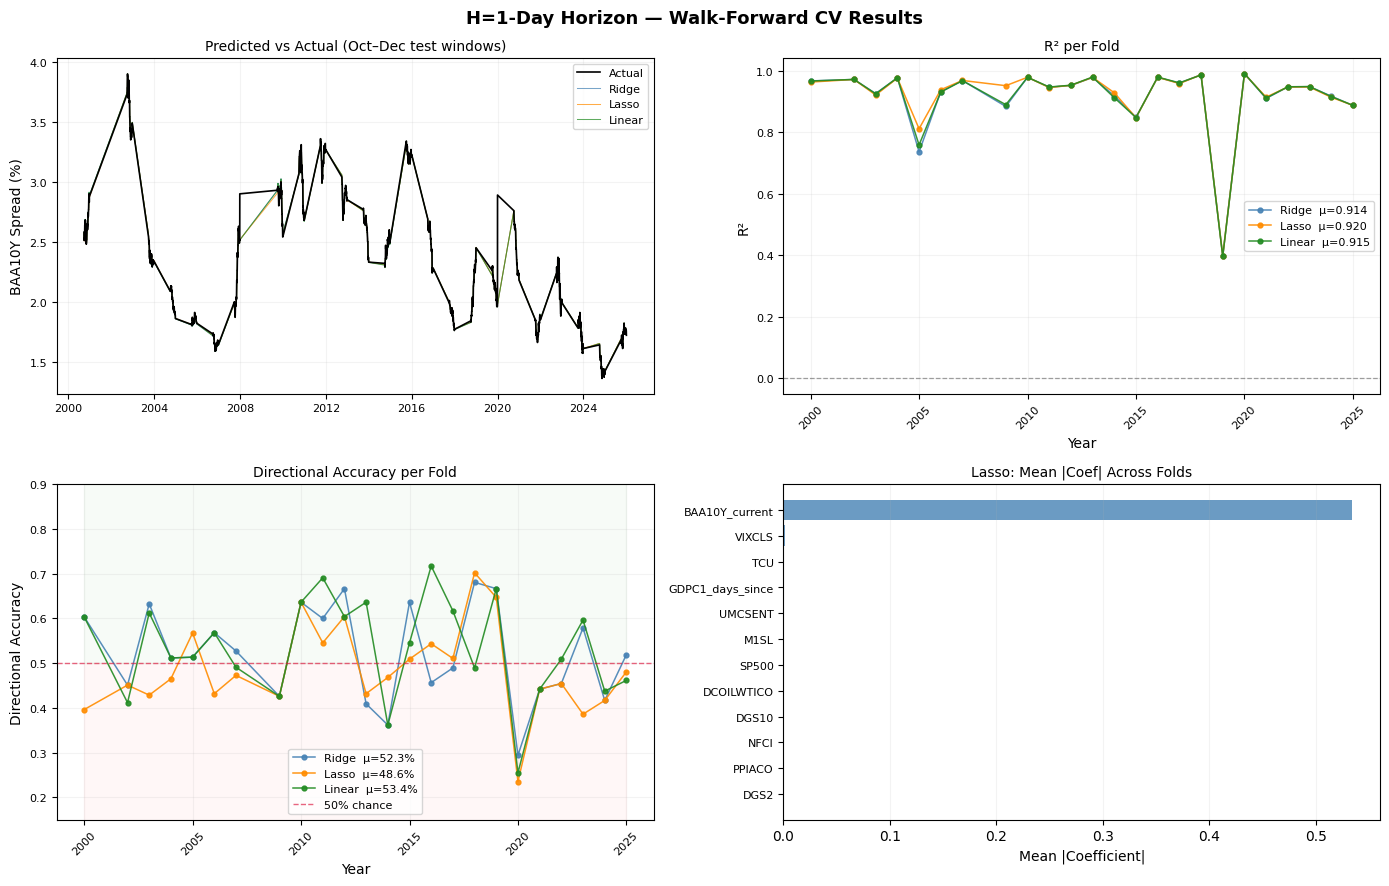

In [37]:
plot_results(results_df_h1, y_test_h1, y_curr_h1, preds_h1, lasso_coefs_h1, feature_names, H=1)

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
act_dir  = np.sign(y_test_h1.values - y_curr_h1.values)
non_flat = act_dir != 0
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Direction Confusion Matrix -- H=1 (DOWN / UP, excl. flat)', fontweight='bold')
for ax, name in zip(axes, ['Ridge', 'Lasso', 'Linear', 'Naive']):
    prd = np.sign(preds_h1[name].values - y_curr_h1.values)
    ConfusionMatrixDisplay.from_predictions(act_dir[non_flat], prd[non_flat],
        labels=[-1, 1], display_labels=['DOWN', 'UP'], cmap='Blues', ax=ax)
    ax.set_title(name)
plt.tight_layout(); plt.show()

## 7-day Horizon

In [38]:
folds = build_folds(H=7)
print(f"Folds: {len(folds)}  ({folds[0]['year']} → {folds[-1]['year']})")
for f in folds[:3] + [folds[-1]]:
    print(f"  {f['year']}: train → {f['X_train'].index.max().date()} "
          f"({len(f['X_train'])} rows) | "
          f"test {f['X_test'].index.min().date()} → "
          f"{f['X_test'].index.max().date()} ({len(f['X_test'])} rows)")

Folds: 24  (2000 → 2025)
  2000: train → 2000-09-30 (3556 rows) | test 2000-10-01 → 2000-12-31 (92 rows)
  2002: train → 2002-09-30 (4011 rows) | test 2002-10-01 → 2002-12-31 (92 rows)
  2003: train → 2003-09-30 (4376 rows) | test 2003-10-01 → 2003-12-31 (92 rows)
  2025: train → 2025-09-30 (11591 rows) | test 2025-10-01 → 2025-12-25 (86 rows)


In [39]:
results_df_h7, y_test_h7, y_curr_h7, preds_h7, lasso_coefs_h7 = run_walk_forward(folds)

2000: Ridge R²= 0.812  Lasso(α=0.001) R²= 0.745  Linear R²= 0.807  Naive MAE=0.0618
2002: Ridge R²= 0.719  Lasso(α=0.001) R²= 0.752  Linear R²= 0.721  Naive MAE=0.0743
2003: Ridge R²= 0.266  Lasso(α=0.001) R²= 0.036  Linear R²= 0.222  Naive MAE=0.0353
2004: Ridge R²= 0.893  Lasso(α=1e-05) R²= 0.891  Linear R²= 0.896  Naive MAE=0.0243
2005: Ridge R²=-3.089  Lasso(α=0.01) R²=-0.066  Linear R²=-3.159  Naive MAE=0.0222
2006: Ridge R²= 0.498  Lasso(α=0.01) R²= 0.304  Linear R²= 0.489  Naive MAE=0.0241
2007: Ridge R²= 0.722  Lasso(α=0.01) R²= 0.756  Linear R²= 0.717  Naive MAE=0.1029
2009: Ridge R²=-2.298  Lasso(α=0.001) R²= 0.519  Linear R²=-2.238  Naive MAE=0.0593
2010: Ridge R²= 0.817  Lasso(α=0.001) R²= 0.808  Linear R²= 0.824  Naive MAE=0.0777
2011: Ridge R²= 0.509  Lasso(α=0.001) R²= 0.436  Linear R²= 0.548  Naive MAE=0.0548
2012: Ridge R²= 0.218  Lasso(α=0.001) R²= 0.263  Linear R²= 0.231  Naive MAE=0.0529
2013: Ridge R²= 0.837  Lasso(α=0.001) R²= 0.823  Linear R²= 0.877  Naive MAE=0.

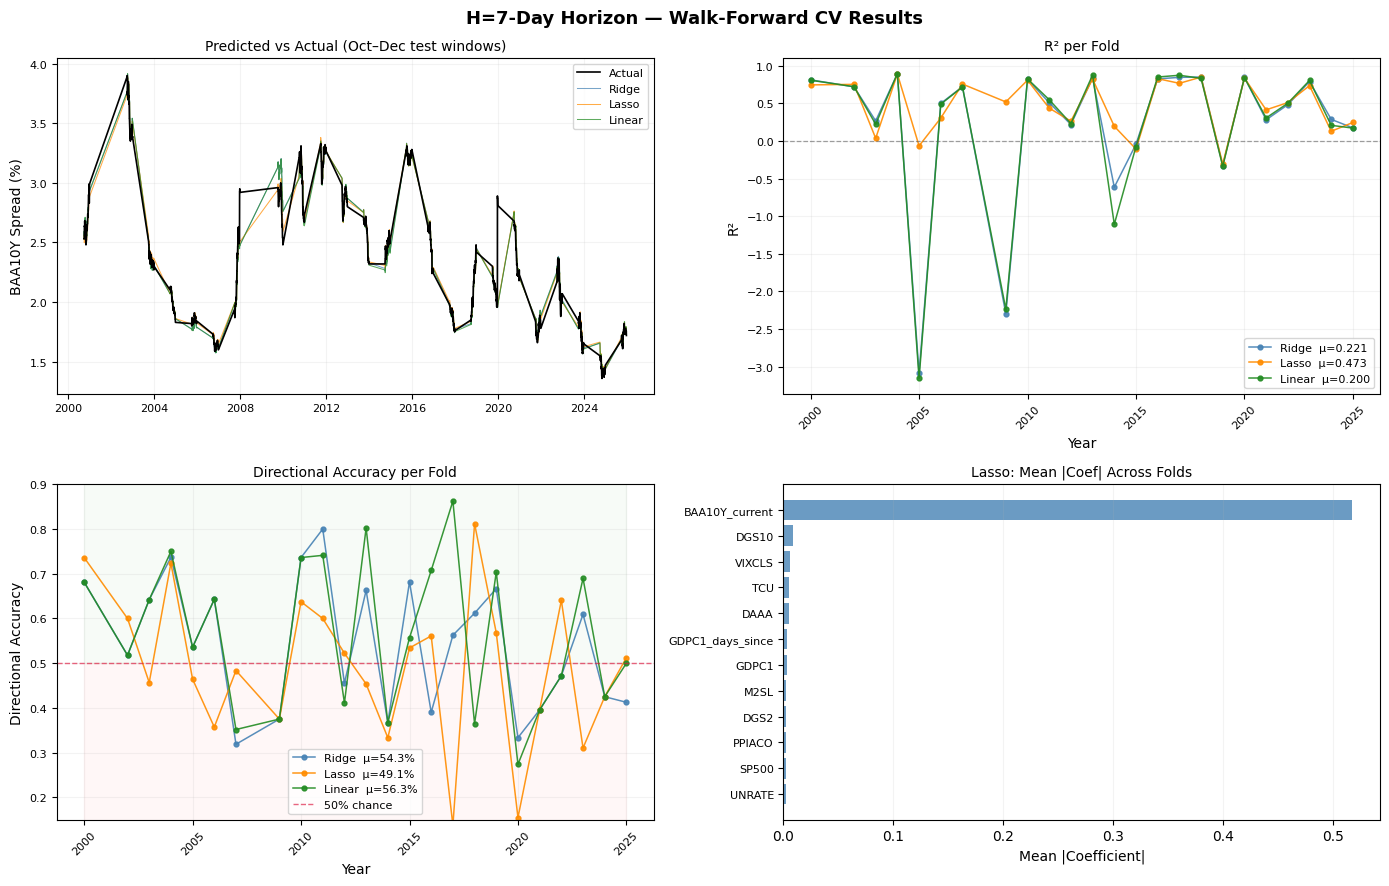

In [40]:
plot_results(results_df_h7, y_test_h7, y_curr_h7, preds_h7, lasso_coefs_h7, feature_names, H=7)

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
act_dir  = np.sign(y_test_h7.values - y_curr_h7.values)
non_flat = act_dir != 0
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Direction Confusion Matrix -- H=7 (DOWN / UP, excl. flat)', fontweight='bold')
for ax, name in zip(axes, ['Ridge', 'Lasso', 'Linear', 'Naive']):
    prd = np.sign(preds_h7[name].values - y_curr_h7.values)
    ConfusionMatrixDisplay.from_predictions(act_dir[non_flat], prd[non_flat],
        labels=[-1, 1], display_labels=['DOWN', 'UP'], cmap='Blues', ax=ax)
    ax.set_title(name)
plt.tight_layout(); plt.show()

## 28-day Horizon

In [41]:
folds = build_folds(H=28)
print(f"Folds: {len(folds)}  ({folds[0]['year']} → {folds[-1]['year']})")
for f in folds[:3] + [folds[-1]]:
    print(f"  {f['year']}: train → {f['X_train'].index.max().date()} "
          f"({len(f['X_train'])} rows) | "
          f"test {f['X_test'].index.min().date()} → "
          f"{f['X_test'].index.max().date()} ({len(f['X_test'])} rows)")

Folds: 24  (2000 → 2025)
  2000: train → 2000-09-30 (3556 rows) | test 2000-10-01 → 2000-12-31 (92 rows)
  2002: train → 2002-09-30 (4011 rows) | test 2002-10-01 → 2002-12-31 (92 rows)
  2003: train → 2003-09-30 (4376 rows) | test 2003-10-01 → 2003-12-31 (92 rows)
  2025: train → 2025-09-30 (11591 rows) | test 2025-10-01 → 2025-12-04 (65 rows)


In [42]:
results_df_h28, y_test_h28, y_curr_h28, preds_h28, lasso_coefs_h28 = run_walk_forward(folds)

2000: Ridge R²=-0.801  Lasso(α=0.001) R²=-0.048  Linear R²=-1.066  Naive MAE=0.1497
2002: Ridge R²=-2.683  Lasso(α=0.001) R²=-1.919  Linear R²=-3.245  Naive MAE=0.1652
2003: Ridge R²=-11.632  Lasso(α=0.01) R²=-9.413  Linear R²=-14.516  Naive MAE=0.0508
2004: Ridge R²= 0.203  Lasso(α=0.01) R²=-0.445  Linear R²= 0.386  Naive MAE=0.0927
2005: Ridge R²=-24.454  Lasso(α=0.1) R²=-3.669  Linear R²=-23.293  Naive MAE=0.0358
2006: Ridge R²=-2.742  Lasso(α=0.001) R²=-3.931  Linear R²=-3.414  Naive MAE=0.0665
2007: Ridge R²=-0.954  Lasso(α=0.01) R²=-0.265  Linear R²=-1.005  Naive MAE=0.2942
2009: Ridge R²=-24.545  Lasso(α=0.01) R²=-0.660  Linear R²=-24.684  Naive MAE=0.1624
2010: Ridge R²= 0.252  Lasso(α=0.01) R²= 0.236  Linear R²= 0.368  Naive MAE=0.1642
2011: Ridge R²=-1.295  Lasso(α=0.01) R²=-1.944  Linear R²=-0.996  Naive MAE=0.1157
2012: Ridge R²=-3.402  Lasso(α=0.01) R²=-3.500  Linear R²=-3.602  Naive MAE=0.1118
2013: Ridge R²= 0.560  Lasso(α=0.01) R²= 0.205  Linear R²= 0.730  Naive MAE=0.1

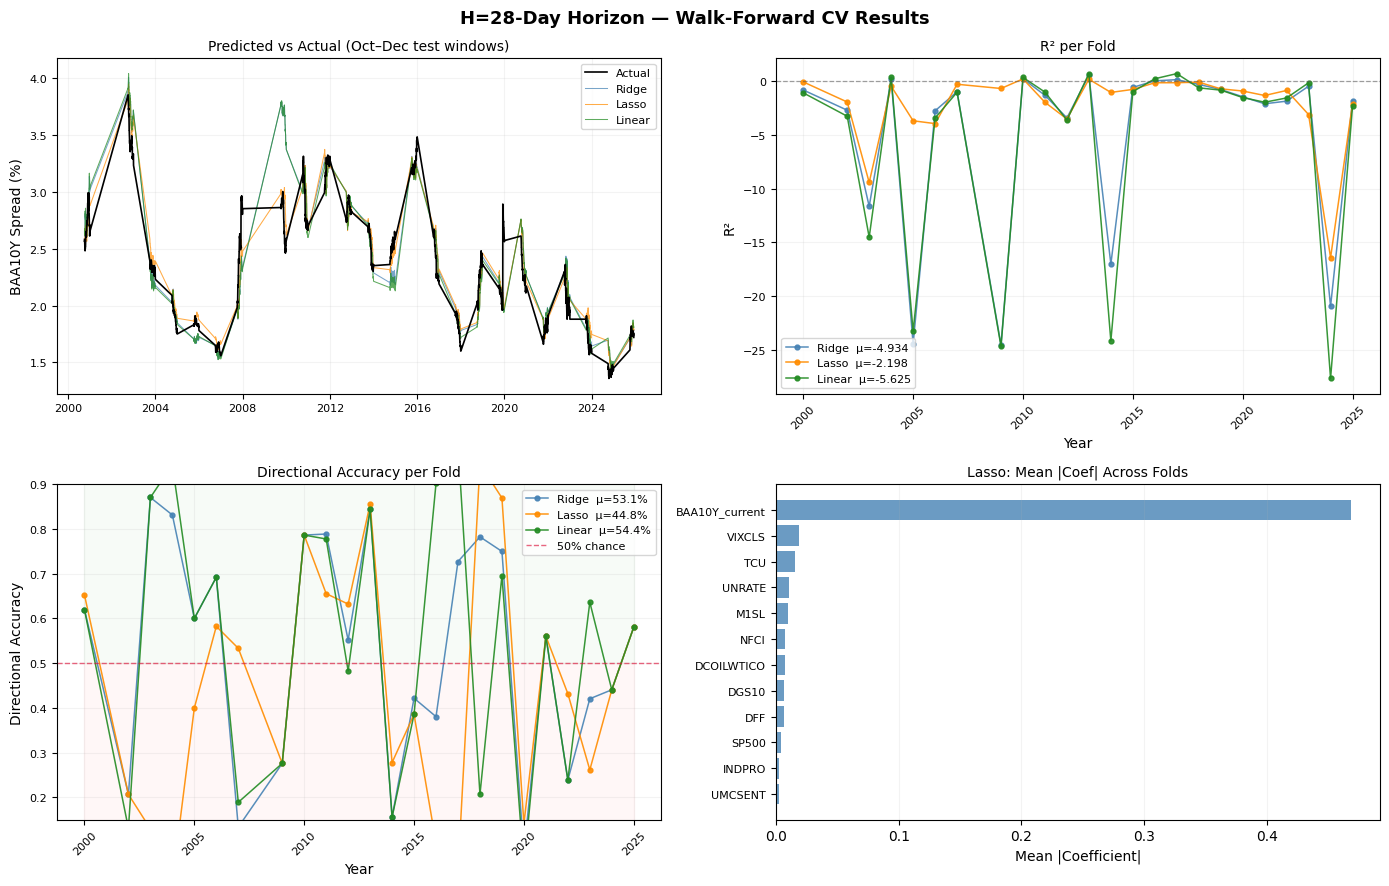

In [43]:
plot_results(results_df_h28, y_test_h28, y_curr_h28, preds_h28, lasso_coefs_h28, feature_names, H=28)

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
act_dir  = np.sign(y_test_h28.values - y_curr_h28.values)
non_flat = act_dir != 0
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Direction Confusion Matrix -- H=28 (DOWN / UP, excl. flat)', fontweight='bold')
for ax, name in zip(axes, ['Ridge', 'Lasso', 'Linear', 'Naive']):
    prd = np.sign(preds_h28[name].values - y_curr_h28.values)
    ConfusionMatrixDisplay.from_predictions(act_dir[non_flat], prd[non_flat],
        labels=[-1, 1], display_labels=['DOWN', 'UP'], cmap='Blues', ax=ax)
    ax.set_title(name)
plt.tight_layout(); plt.show()

## Summary

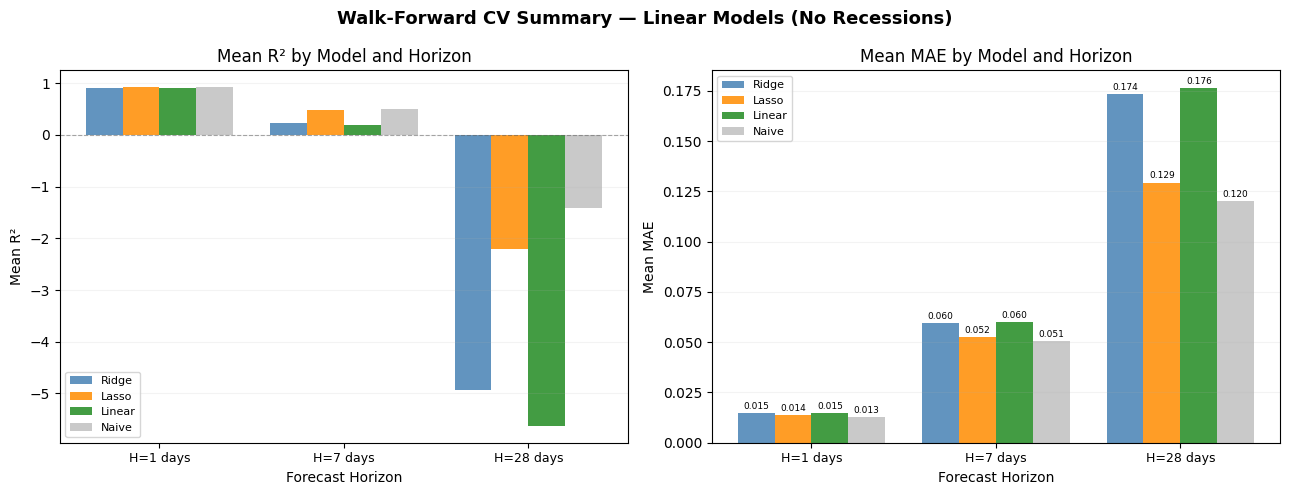

In [44]:
horizons     = [1, 7, 28]
results_by_h = {1: results_df_h1, 7: results_df_h7, 28: results_df_h28}
model_names  = ['Ridge', 'Lasso', 'Linear', 'Naive']
colors_map   = {**MC, 'Naive': 'silver'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Walk-Forward CV Summary — Linear Models (No Recessions)',
             fontsize=13, fontweight='bold')

x = np.arange(len(horizons))
width = 0.2

# ── Mean R² ──────────────────────────────────────────────────────────────────
ax = axes[0]
for i, name in enumerate(model_names):
    vals = [results_by_h[h][f'R2_{name}'].mean() for h in horizons]
    ax.bar(x + i * width, vals, width, label=name, color=colors_map[name], alpha=0.85)
ax.axhline(0, color='#555', lw=0.8, linestyle='--', alpha=0.5)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f'H={h} days' for h in horizons], fontsize=9)
ax.set_xlabel('Forecast Horizon')
ax.set_ylabel('Mean R²')
ax.set_title('Mean R² by Model and Horizon')
ax.legend(fontsize=8, framealpha=0.8)
ax.grid(True, axis='y', alpha=0.15)

# ── Mean MAE ─────────────────────────────────────────────────────────────────
ax = axes[1]
for i, name in enumerate(model_names):
    vals = [results_by_h[h][f'MAE_{name}'].mean() for h in horizons]
    bars = ax.bar(x + i * width, vals, width, label=name,
                  color=colors_map[name], alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=6.5)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f'H={h} days' for h in horizons], fontsize=9)
ax.set_xlabel('Forecast Horizon')
ax.set_ylabel('Mean MAE')
ax.set_title('Mean MAE by Model and Horizon')
ax.legend(fontsize=8, framealpha=0.8)
ax.grid(True, axis='y', alpha=0.15)

plt.tight_layout()
plt.show()